In [ ]:
import numpy as np
import h5py


fn = "image1-competition.hdf5"

with h5py.File(fn, "r") as f:
    data = np.array(f["data"])
    wns = np.array(f["wns"])
    tissue_mask = np.array(f["tissue_mask"])
    classes = np.array(f["classes"])

Name: classes
  Shape: (934, 1300)
  Type:  int8
Name: data
  Shape: (934, 1300, 187)
  Type:  float32
Name: tissue_mask
  Shape: (934, 1300)
  Type:  bool
Name: wns
  Shape: (187,)
  Type:  float32


In [32]:
wns

array([1000., 1004., 1008., 1012., 1016., 1020., 1024., 1028., 1032.,
       1036., 1040., 1044., 1048., 1052., 1056., 1060., 1064., 1068.,
       1072., 1076., 1080., 1084., 1088., 1092., 1096., 1100., 1104.,
       1108., 1112., 1116., 1120., 1124., 1128., 1132., 1136., 1140.,
       1144., 1148., 1152., 1156., 1160., 1164., 1168., 1172., 1176.,
       1180., 1184., 1188., 1192., 1196., 1200., 1204., 1208., 1212.,
       1216., 1220., 1224., 1228., 1232., 1236., 1240., 1244., 1248.,
       1252., 1256., 1260., 1264., 1268., 1272., 1276., 1280., 1284.,
       1288., 1292., 1296., 1300., 1304., 1308., 1312., 1316., 1320.,
       1324., 1328., 1332., 1336., 1340., 1344., 1348., 1352., 1356.,
       1360., 1364., 1368., 1372., 1376., 1380., 1384., 1388., 1392.,
       1396., 1400., 1404., 1408., 1412., 1416., 1420., 1424., 1428.,
       1432., 1436., 1440., 1444., 1448., 1452., 1456., 1460., 1464.,
       1468., 1472., 1476., 1480., 1484., 1488., 1492., 1496., 1500.,
       1504., 1508.,

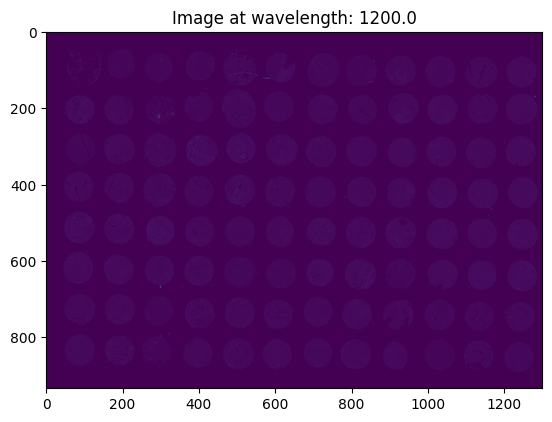

In [ ]:
import matplotlib.pyplot as plt

# Take the 50th spectral band
# data[height, width, band]
sample_slice = data[:, :, 170]

plt.imshow(sample_slice)
plt.title(f"Image at wavelength: {wns[170]}")
plt.show()

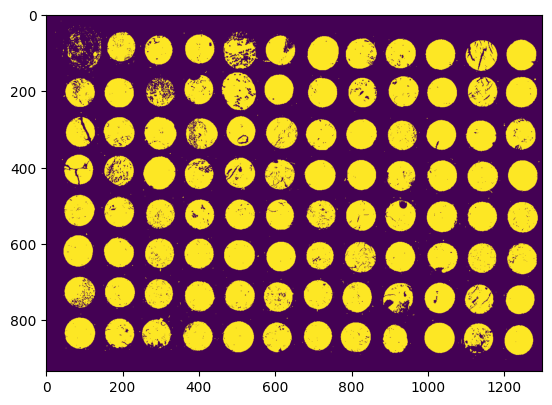

In [18]:
# display the whole image

import matplotlib.pyplot as plt

def nearest_ind(a, v):
    return np.abs(a - v).argmin()

im = data[:, :, nearest_ind(wns, 1650)]
plot = plt.imshow(im, vmin=0, vmax=1)

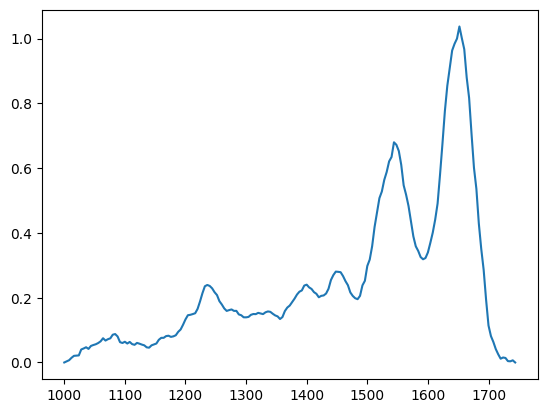

In [3]:
# a single "pixel" is a spectrum
plt.plot(wns, data[600, 200])
plt.show()

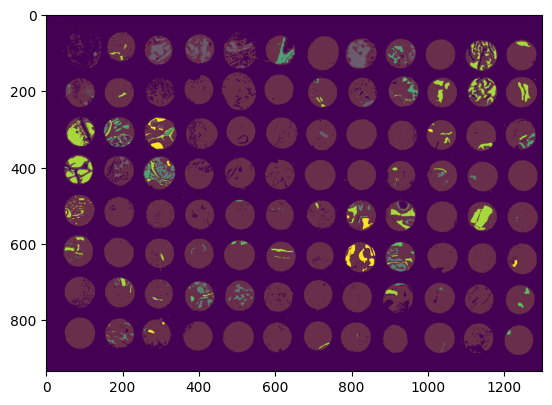

In [19]:
# the classes
plt.imshow(data[:, :, nearest_ind(wns, 1650)], vmin=0, vmax=1)
plt.imshow(classes[:, :], alpha=0.8)

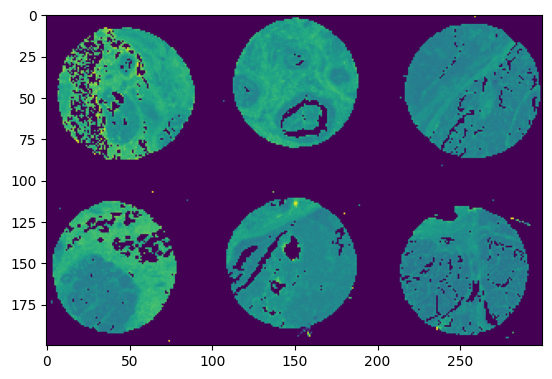

In [21]:
data_predict = data[265:465,360:660]
plt.imshow(data_predict[:, :, nearest_ind(wns, 1560)], vmin=0, vmax=1)

In [6]:
# Multinomial Logistic Regresion that disregards image coordinates

annotated_sel = classes != -1
X = data[annotated_sel]
y = classes[annotated_sel]

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=10000, C=0.001)
lr.fit(X, y)


LogisticRegression(C=0.001, max_iter=10000)

In [7]:
# take spectra for prediction in a linearized sequence
lin_data_predict = data_predict.reshape(-1, data_predict.shape[-1])
lin_data_predict = scaler.transform(lin_data_predict)

lin_pred = lr.predict_proba(lin_data_predict)
pred = lin_pred.reshape(data_predict.shape[:2] + lin_pred.shape[-1:])

with open("multilogreg.npy", "wb") as f:
    np.save(f, pred.astype(np.float32))